Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 — Load Dataset

In [2]:
df = pd.read_csv("../data/DisasterDeclarations.csv")
df.head()

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


Step 3 — Validate Time Data

In [3]:
df['declarationDate'] = pd.to_datetime(df['declarationDate'])
df['incidentBeginDate'] = pd.to_datetime(df['incidentBeginDate'])
df['incidentEndDate'] = pd.to_datetime(df['incidentEndDate'])

In [4]:
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

In [5]:
df['declarationDate'].isnull().sum()

np.int64(0)

Step 4 — Yearly Trend Analysis
Group disasters by year.

In [6]:
yearly_disasters = df.groupby('year').size()
yearly_disasters.head()

year
1953    13
1954    17
1955    18
1956    16
1957    16
dtype: int64

Visualization

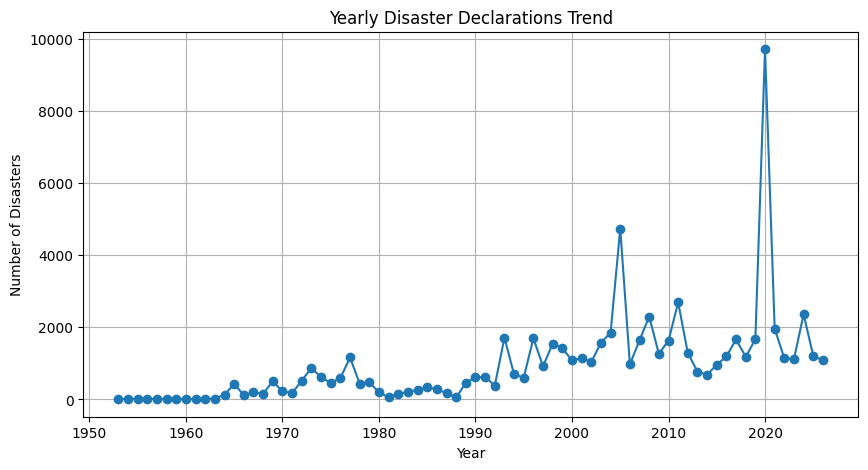

In [7]:
plt.figure(figsize=(10,5))

plt.plot(yearly_disasters, marker='o')

plt.title("Yearly Disaster Declarations Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.grid(True)

plt.show()

Observation:
The plot shows how disaster declarations change over time.

Pattern:
There is an increasing trend in disaster declarations in recent years.

Possible Reason:
Climate change and improved disaster reporting systems.

Step 5 — Incident Type Trends Over Time

Group by year and incident type

In [8]:
incident_trend = df.groupby(['year','incidentType']).size().unstack()
incident_trend.head()

incidentType,Biological,Chemical,Coastal Storm,Dam/Levee Break,Drought,Earthquake,Fire,Fishing Losses,Flood,Freezing,...,Straight-Line Winds,Terrorist,Tornado,Toxic Substances,Tropical Depression,Tropical Storm,Tsunami,Typhoon,Volcanic Eruption,Winter Storm
year,,,,,,,,,,,,,,,,,,,,,
1953,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,5.0,NaN,...,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,7.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1956,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,7.0,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,...,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Visualization

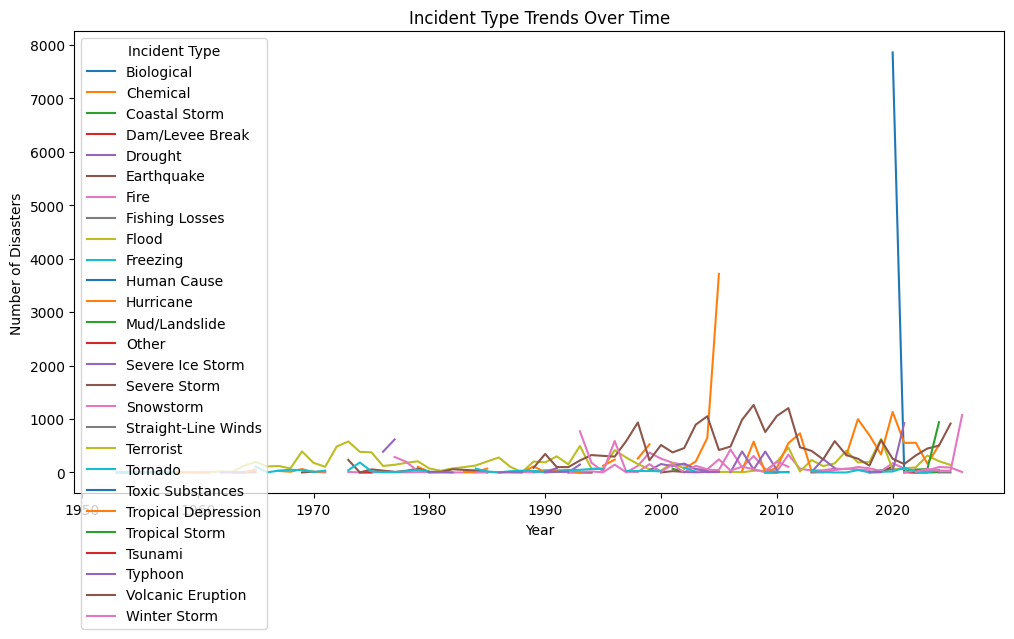

In [9]:
incident_trend.plot(figsize=(12,6))

plt.title("Incident Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.legend(title="Incident Type")

plt.show()

Observation:
Different disaster types vary across years.

Pattern:
Storms and floods appear more frequently than other disaster types.

Possible Reason:
Extreme weather events are becoming more common.

Step 6 — Monthly Seasonality Analysis

Group by month.

In [10]:
monthly_disasters = df.groupby('month').size()
monthly_disasters

month
1      6111
2      4830
3     11127
4      6998
5      5211
6      4931
7      5101
8      5849
9     11721
10     4007
11     1674
12     2074
dtype: int64

visualization

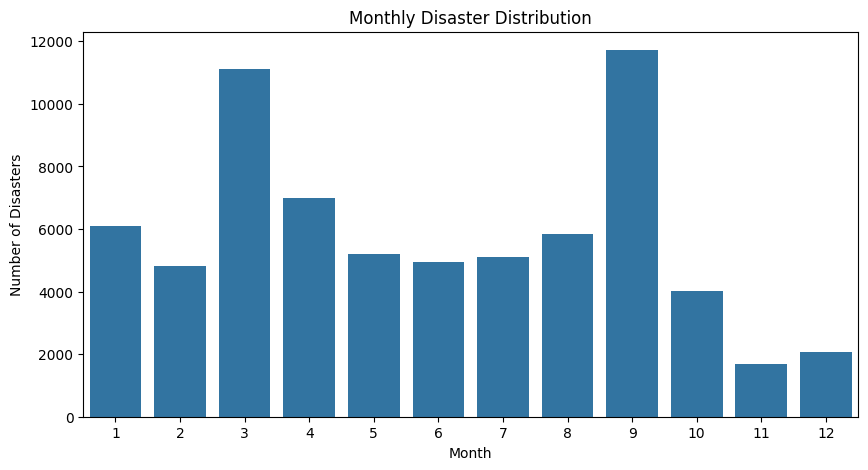

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(x=monthly_disasters.index, y=monthly_disasters.values)

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

insight

Observation:
Some months show higher disaster declarations.

Pattern:
Summer and hurricane season months tend to have more disasters.

Possible Reason:
Seasonal weather patterns like hurricanes and floods.

Step 7 — Advanced Time Insights
Rolling Average (3-year smoothing)

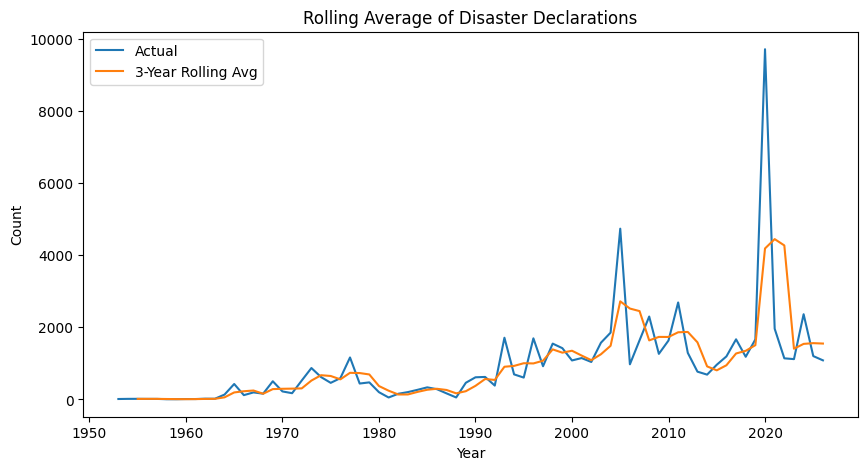

In [12]:
rolling_avg = yearly_disasters.rolling(window=3).mean()

plt.figure(figsize=(10,5))

plt.plot(yearly_disasters, label="Actual")
plt.plot(rolling_avg, label="3-Year Rolling Avg")

plt.title("Rolling Average of Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend()

plt.show()

Growth Rate (Year-over-Year)

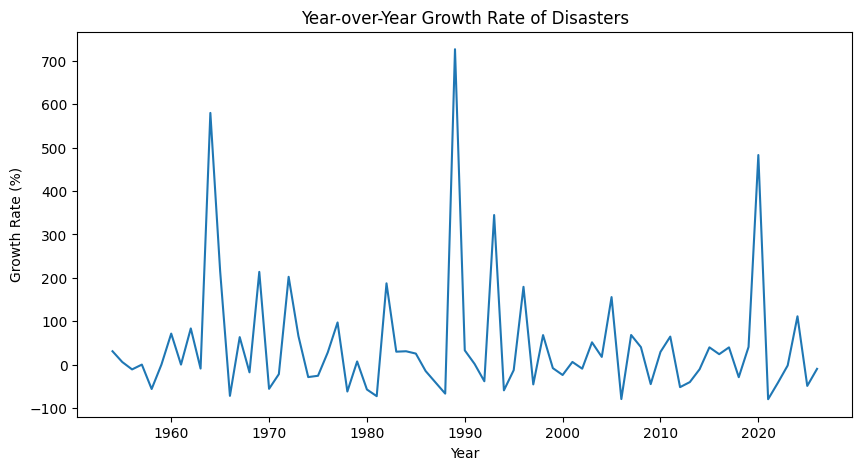

In [13]:
growth_rate = yearly_disasters.pct_change()*100

plt.figure(figsize=(10,5))

plt.plot(growth_rate)

plt.title("Year-over-Year Growth Rate of Disasters")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.show()

Step 8 — Identify Peak Disaster Years

In [14]:
top_years = yearly_disasters.sort_values(ascending=False).head(5)

top_years

year
2020    9712
2005    4736
2011    2690
2024    2364
2008    2300
dtype: int64

Step 9 — Final Insight Summary

Key Findings:

1. Disaster declarations have increased over the past decades.
2. Storms and floods are the most common disaster types.
3. Certain months show clear seasonal patterns.
4. Rolling averages confirm a long-term upward trend.

Heatmap of Disasters by Year and Month


Step 1 — Create Pivot Table

In [15]:
pivot_table = df.pivot_table(
    index='month',
    columns='year',
    aggfunc='size'
)

Step 2 — Create Heatmap

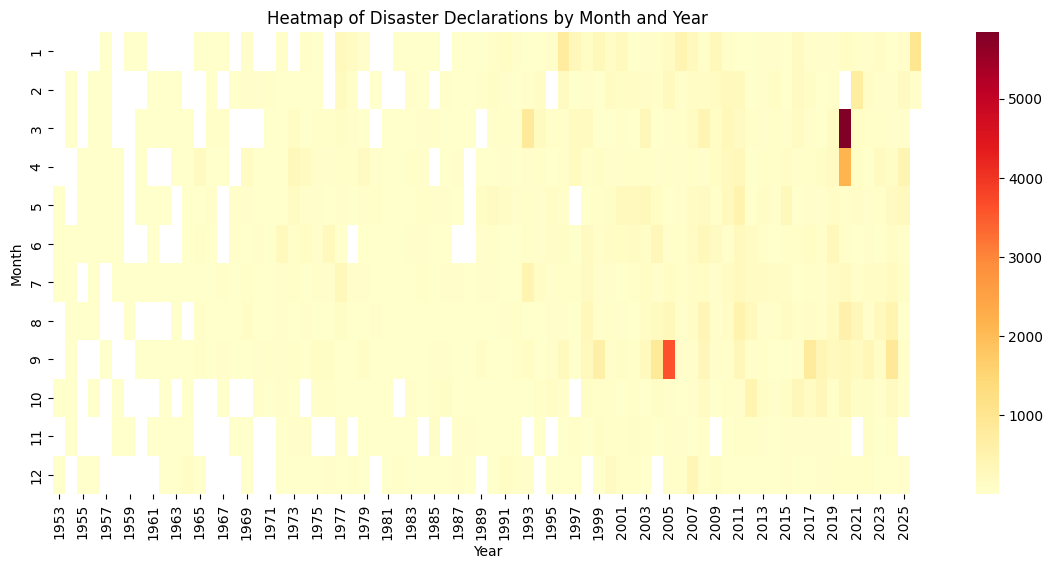

In [16]:
plt.figure(figsize=(14,6))

sns.heatmap(pivot_table, cmap="YlOrRd")

plt.title("Heatmap of Disaster Declarations by Month and Year")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

What This Graph Shows

-->Dark colors → More disasters

-->Light colors → Fewer disasters

You can easily see:

*seasonal patterns

*years with many disasters

*months with highest disaster frequency

Observation:
The heatmap visualizes disaster declarations across months and years.

Pattern:
Certain months consistently show higher disaster counts.

Interpretation:
Seasonal weather events such as hurricanes and storms contribute to higher disaster frequency in specific months.

Top 10 States Disaster Trend Over Time (Multi-Line Chart).

Step 1 — Find Top 10 States with Most Disasters

In [17]:
top_states = df['state'].value_counts().head(10).index

top_states

Index(['TX', 'KY', 'MO', 'FL', 'GA', 'VA', 'LA', 'OK', 'NC', 'PR'], dtype='object', name='state')

Step 2 — Filter Dataset for These States

In [18]:
top_states_df = df[df['state'].isin(top_states)]

Step 3 — Group by Year and State

In [19]:
state_year_trend = top_states_df.groupby(['year','state']).size().unstack()

Step 4 — Plot Multi-Line Chart

<Figure size 1200x600 with 0 Axes>

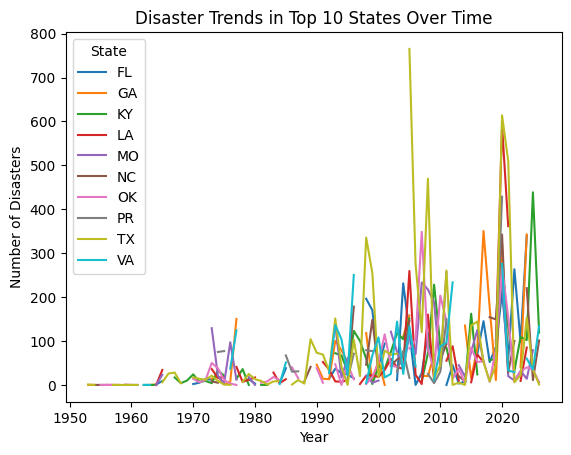

In [20]:
plt.figure(figsize=(12,6))

state_year_trend.plot()

plt.title("Disaster Trends in Top 10 States Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.legend(title="State")

plt.show()

Observation:
The chart shows disaster trends for the top 10 states with the highest number of disaster declarations.

Pattern:
States like Texas, California, and Florida consistently experience higher disaster declarations compared to others.

Possible Reason:
These states are more exposed to natural hazards such as hurricanes, wildfires, and floods.